# Pixel Operations Notebook

This notebook combines:
- `pixel_modification.py`
- `pixel_slicing.py`
- `pixel_resizing.py`


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def get_image_path(filename: str) -> Path:
    candidates = [Path(filename), Path('session2') / filename]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f'Could not find {filename}. Checked: {candidates}')

def read_image(filename: str):
    p = get_image_path(filename)
    img = cv2.imread(str(p))
    if img is None:
        raise FileNotFoundError(f'Could not read image at: {p}')
    return img, p

def show_bgr(title: str, img):
    plt.figure(figsize=(7, 5))
    plt.title(title)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


## 1) Pixel Modification (loop)
Equivalent of `pixel_modification.py`


Loaded: 1.jpg


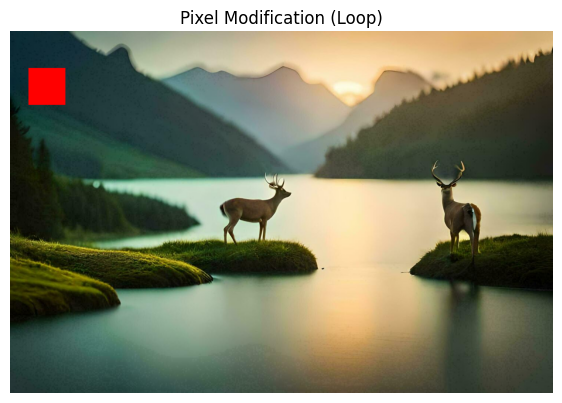

In [2]:
image, image_path = read_image('1.jpg')
print(f'Loaded: {image_path}')

x_start, x_end = 50, 150
y_start, y_end = 100, 200

modified = image.copy()
for y in range(y_start, y_end):
    for x in range(x_start, x_end):
        modified[y, x] = [0, 0, 255]  # Red in BGR

show_bgr('Pixel Modification (Loop)', modified)


## 2) Pixel Slicing (ROI assignment)
Equivalent of `pixel_slicing.py`


Loaded: 1.jpg


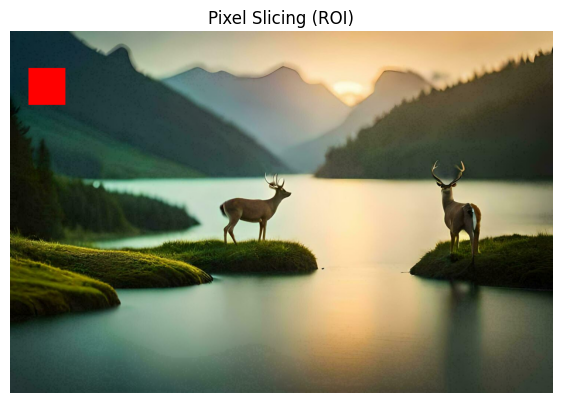

In [3]:
image2, image2_path = read_image('1.jpg')
print(f'Loaded: {image2_path}')

x_start, x_end = 50, 150
y_start, y_end = 100, 200

sliced = image2.copy()
sliced[y_start:y_end, x_start:x_end] = [0, 0, 255]

show_bgr('Pixel Slicing (ROI)', sliced)


## 3) Pixel Resizing (100%, 50%, 15%)
Equivalent of `pixel_resizing.py` in one combined view


Loaded: 1.jpg
Image Dimensions: 1470x980, Channels: 3


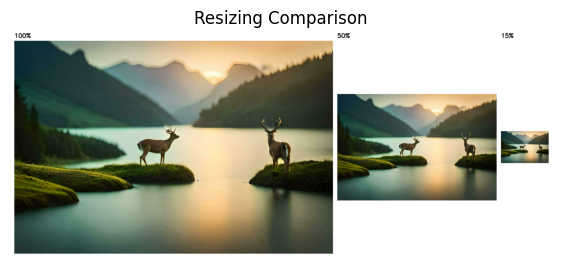

In [4]:
image3, image3_path = read_image('1.jpg')
print(f'Loaded: {image3_path}')

height, width, channels = image3.shape
print(f'Image Dimensions: {width}x{height}, Channels: {channels}')

scale_100 = image3.copy()
scale_50 = cv2.resize(image3, (int(width * 0.50), int(height * 0.50)))
scale_15 = cv2.resize(image3, (int(width * 0.15), int(height * 0.15)))

images = [('100%', scale_100), ('50%', scale_50), ('15%', scale_15)]
gap = 20
top_pad = 45
max_h = max(img.shape[0] for _, img in images)
total_w = sum(img.shape[1] for _, img in images) + gap * (len(images) + 1)
canvas = np.full((top_pad + max_h + gap, total_w, 3), 255, dtype=np.uint8)

x = gap
for label, img in images:
    h, w = img.shape[:2]
    y = top_pad + (max_h - h) // 2
    canvas[y:y+h, x:x+w] = img
    cv2.putText(canvas, label, (x, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2, cv2.LINE_AA)
    x += w + gap

show_bgr('Resizing Comparison', canvas)


## Resizing Images - Algorithms

If you don't specify an interpolation method, OpenCV defaults to `cv2.INTER_LINEAR`.

| Interpolation Method | Description | Best For |
|---|---|---|
| `cv2.INTER_NEAREST` | Nearest-neighbor without interpolation (fastest, low quality) | Simple graphics, pixel art |
| `cv2.INTER_LINEAR` | Bilinear interpolation of nearest 4 neighboring pixels (default, moderate quality) | General resizing |
| `cv2.INTER_CUBIC` | Bicubic interpolation (uses 16 pixels, higher quality but slower) | High-quality resizing |
| `cv2.INTER_LANCZOS4` | Lanczos interpolation (uses 8×8 pixel neighborhood, best quality) | High-resolution images |
| `cv2.INTER_AREA` | Area-based resampling (reduces noise, best for downscaling) | Shrinking images |

### Example Usage:
```python
import cv2

# Read image
image = cv2.imread("image.jpg")

# Resize with different interpolation methods
resized_linear = cv2.resize(image, (300, 300), interpolation=cv2.INTER_LINEAR)
resized_cubic = cv2.resize(image, (300, 300), interpolation=cv2.INTER_CUBIC)
resized_lanczos = cv2.resize(image, (300, 300), interpolation=cv2.INTER_LANCZOS4)
resized_area = cv2.resize(image, (300, 300), interpolation=cv2.INTER_AREA)
```

### Resizing and cropping

Original: 1470x980 | Resized: 2940x1960 | Cropped: 400x300


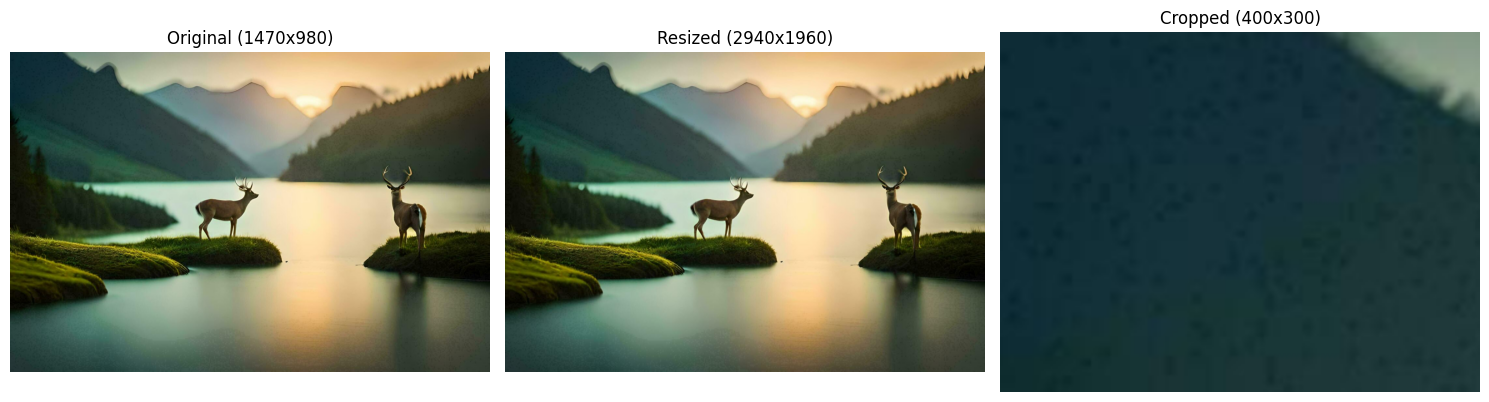

In [5]:
# Load image for resizing and cropping example
image4, _ = read_image('1.jpg')
height, width, channels = image4.shape

# Resize the image with given proportion
proportion = 2.0
# Desired width and height - cast to int
new_width, new_height = int(width * proportion), int(height * proportion)  
resized_image = cv2.resize(image4, (new_width, new_height), cv2.INTER_CUBIC)

# Crop a region of interest (ROI) using NumPy slicing
# Adjust coordinates to fit within resized image dimensions
x_start, x_end = 100, 500    # Columns (Width)
y_start, y_end = 50, 350     # Rows (Height)
cropped_image = resized_image[y_start:y_end, x_start:x_end]

print(f'Original: {width}x{height} | Resized: {new_width}x{new_height} | Cropped: {cropped_image.shape[1]}x{cropped_image.shape[0]}')

# Display comparison: Original vs Resized vs Cropped
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(cv2.cvtColor(image4, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Original ({width}x{height})')
axes[0].axis('off')

# Resized image
axes[1].imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Resized ({new_width}x{new_height})')
axes[1].axis('off')

# Cropped image
axes[2].imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Cropped ({cropped_image.shape[1]}x{cropped_image.shape[0]})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Flipping and rotating images at 90°


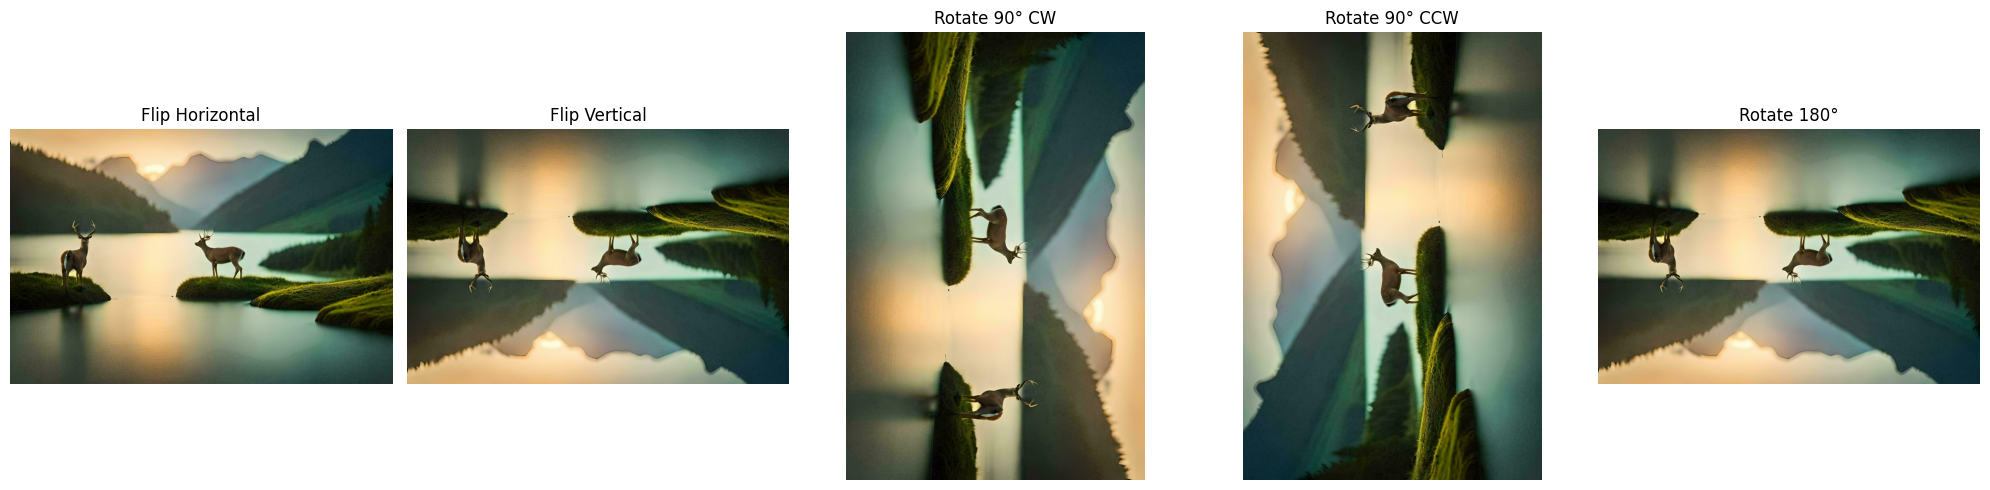

In [6]:
#Flipping and rotating images at 90°
flip_horizontal = cv2.flip(image4, 1)  # Horizontal flip
flip_vertical = cv2.flip(image4, -1)    # Vertical flip
rotate_90_clockwise = cv2.rotate(image4, cv2.ROTATE_90_CLOCKWISE)
rotate_90_counterclockwise = cv2.rotate(image4, cv2.ROTATE_90_COUNTERCLOCKWISE)


rotate_180_horizontal = cv2.flip(image4, -1)  # Flip both axes (180° rotation)
rotate_180_vertical = cv2.flip(image4, -1)    # Same as horizontal flip for 180°

axes = [flip_horizontal, flip_vertical, rotate_90_clockwise, rotate_90_counterclockwise, rotate_180_horizontal]
titles = ['Flip Horizontal', 'Flip Vertical', 'Rotate 90° CW', 'Rotate 90° CCW', 'Rotate 180°'] 
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
for ax, img, title in zip(axs, axes, titles):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 4) Rotate an Image by a Custom Angle and Scale Using a Rotation Matrix

Rotation of a 2D image by an angle $\theta$ is described by:

$$\mathbf{x'} = \mathbf{R}\mathbf{x}$$

where

$$\mathbf{R} = \begin{bmatrix}\cos\theta & -\sin\theta\\\sin\theta & \cos\theta\end{bmatrix},\quad\mathbf{x}=\begin{bmatrix}x\\y\end{bmatrix},\quad\mathbf{x'}=\begin{bmatrix}x'\\y'\end{bmatrix}$$

So the rotated coordinates are:

$$x' = x\cos\theta - y\sin\theta$$

$$y' = x\sin\theta + y\cos\theta$$

In OpenCV, scaled rotation with a custom center $(c_x, c_y)$ is used. The modified transformation matrix is:

$$\mathbf{M}=\begin{bmatrix}\alpha & \beta & (1-\alpha)c_x-\beta c_y\\-\beta & \alpha & \beta c_x+(1-\alpha)c_y\end{bmatrix}$$

with

$$\alpha=s\cos\theta,\quad\beta=s\sin\theta$$

where $\theta$ is the rotation angle, $s$ is the scale factor, and $(c_x,c_y)$ is the rotation center.


### Rotate an Image by a Custom Angle and scaling


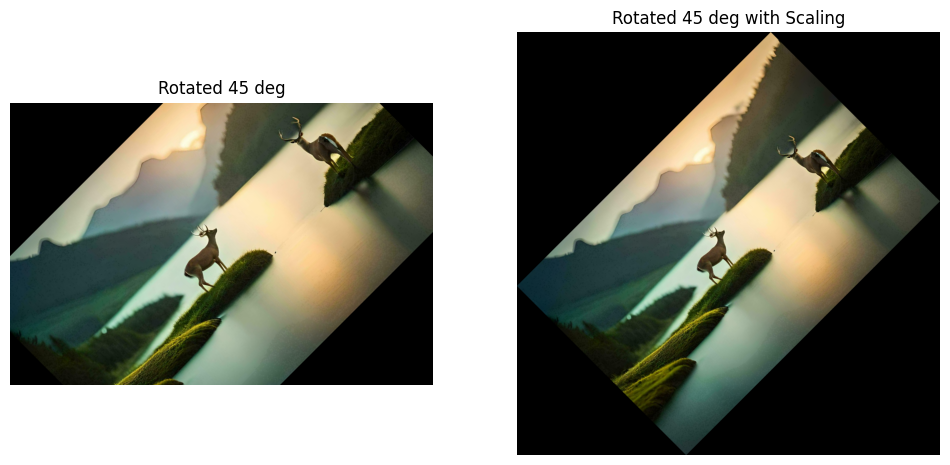

In [7]:
#Rotate an Image by a Custom Angle and scaling 
angle = 45  # Rotation angle in degrees
scale = 1.0  # Scaling factor (1.0 means no scaling)

center = (width // 2, height // 2)
#get the rotation matrix for the specified angle and scale
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
rotated_image = cv2.warpAffine(image4, rotation_matrix, (width, height))

cos_angle = np.abs(rotation_matrix[0, 0])
sin_angle = np.abs(rotation_matrix[0, 1])
new_width = int((height * sin_angle) + (width * cos_angle))
new_height = int((height * cos_angle) + (width * sin_angle))
rotation_matrix[0, 2] += (new_width / 2) - center[0]
rotation_matrix[1, 2] += (new_height / 2) - center[1]

#rotate the image with the updated rotation matrix and new dimensions
rotated_scaled_image = cv2.warpAffine(image4, rotation_matrix, (new_width, new_height))
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(rotated_image, cv2.COLOR_BGR2RGB))
plt.title(f'Rotated {angle} deg')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(rotated_scaled_image, cv2.COLOR_BGR2RGB))
plt.title(f'Rotated {angle} deg with Scaling')
plt.axis('off')
plt.show()




## 5) Perspective (Projective) Transformation and Warping

Perspective transformation allows us to change the viewpoint of an image, making it look as if viewed from a different angle. Straight lines remain straight after the transformation.

For perspective transformation, you need a 3x3 perspective transformation matrix $\mathbf{H}$:

$$\mathbf{x'} = \mathbf{H}\mathbf{x}$$

To find this transformation matrix, you need 4 points on the input image and the corresponding 4 points on the output image. Among these points, at least 3 must not be collinear.

Then the transformation matrix can be computed using `cv.getPerspectiveTransform`, and the transformed image can be generated using `cv.warpPerspective` with this 3x3 matrix.


### Changing Color Space

OpenCV provides more than 150 color-space conversion options.  
To convert an image from one color space to another, use:

`cv2.cvtColor(src, code)`

- `src`: input image  
- `code`: conversion flag (defines the target color space)

Commonly used flags:

- `cv2.COLOR_BGR2GRAY` : BGR to Grayscale  
- `cv2.COLOR_BGR2HSV` : BGR to HSV  
- `cv2.COLOR_BGR2RGB` : BGR to RGB  

**Note:** OpenCV reads images in **BGR** (Blue-Green-Red) order by default, not RGB (Red-Green-Blue).


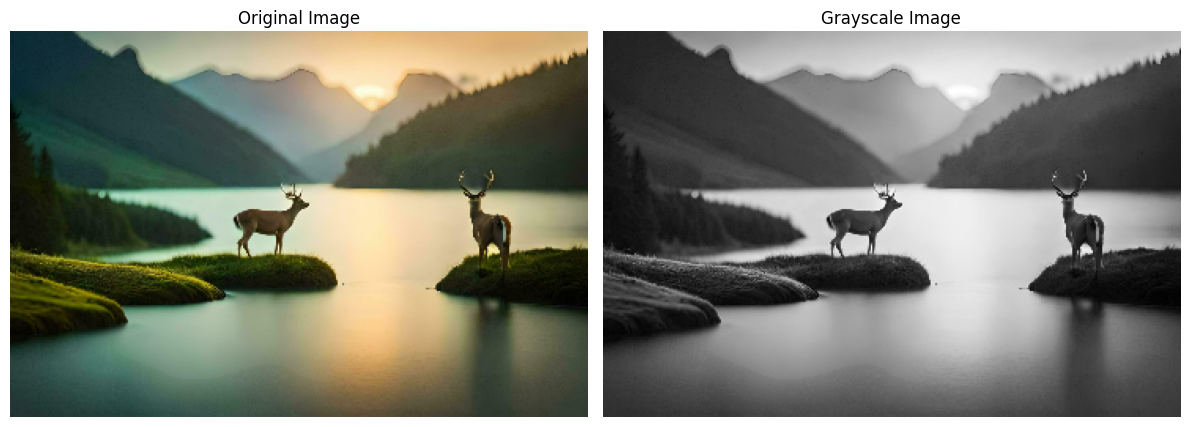

In [4]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Changing Color-space example
image_path = Path("1.jpg")
image = cv2.imread(str(image_path))
if image is None:
    raise FileNotFoundError(f"Could not read image at: {image_path}")

height, width, channels = image.shape
proportion = 0.25
new_width, new_height = int(width * proportion), int(height * proportion)

resized_image = cv2.resize(image, (new_width, new_height))
image_gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

# Show image using matplotlib
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.tight_layout()
plt.show()


### Image Addition

You can add two images using OpenCV:

`cv2.add(img1, img2)`

or using NumPy:

`result = img1 + img2`

Both images should have the same size, depth, and type.  
You can also add a scalar value to an image.

**Important:** OpenCV addition and NumPy addition are different.

- **OpenCV addition** is **saturated** (values are clipped to 255 for `uint8`).
- **NumPy addition** is **modulo** (values wrap around after 255).

Example:

```python
import numpy as np
import cv2

x = np.uint8([250])
y = np.uint8([10])

print(cv2.add(x, y))  # 250 + 10 = 260 -> 255 (clipped)
print(x + y)          # 250 + 10 = 260 % 256 = 4 (wrapped)



### Image Addition


Resizing images to match dimensions...


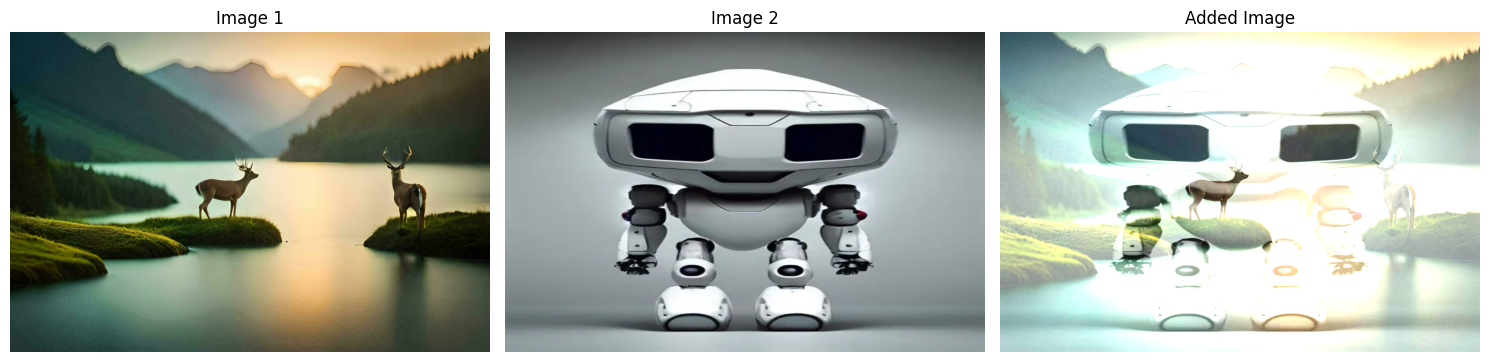

In [5]:
import cv2
import matplotlib.pyplot as plt

image1 = cv2.imread("1.jpg")
image2 = cv2.imread("2.jpg")

# Check if images loaded correctly
if image1 is None or image2 is None:
    raise FileNotFoundError("Error: One or both images could not be loaded.")

# Resize image2 if shapes differ
if image1.shape != image2.shape:
    print("Resizing images to match dimensions...")
    image2 = cv2.resize(image2, (image1.shape[1], image1.shape[0]))

# Add images
added_image = cv2.add(image1, image2)

# Convert BGR -> RGB for matplotlib
image1_rgb = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
added_image_rgb = cv2.cvtColor(added_image, cv2.COLOR_BGR2RGB)

# Show all 3 in one figure
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image1_rgb)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(image2_rgb)
plt.title("Image 2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(added_image_rgb)
plt.title("Added Image")
plt.axis("off")

plt.tight_layout()
plt.show()
